# Mapa rugosidad tenerife en pixeles de 5.5x7km (Resolución TROPOMI)

In [2]:
!pip install geopandas

     -------------------------------------- 323.6/323.6 kB 4.0 MB/s eta 0:00:00
     --------------------------------------- 19.2/19.2 MB 31.2 MB/s eta 0:00:00
     ---------------------------------------- 1.4/1.4 MB 30.5 MB/s eta 0:00:00


In [5]:
!pip install osmnx

     -------------------------------------- 101.5/101.5 kB 2.9 MB/s eta 0:00:00


In [8]:
!pip install rasterio rasterstats

     ---------------------------------------- 90.5/90.5 kB 1.7 MB/s eta 0:00:00
     --------------------------------------- 24.5/24.5 MB 13.1 MB/s eta 0:00:00


1/3 - Descargando la silueta exacta de Tenerife...
2/3 - Generando la cuadrícula de TROPOMI (5.5x7 km)...
3/3 - Calculando la rugosidad REAL cruzando con el mapa 3D...
¡Listo! Dibujando el mapa...


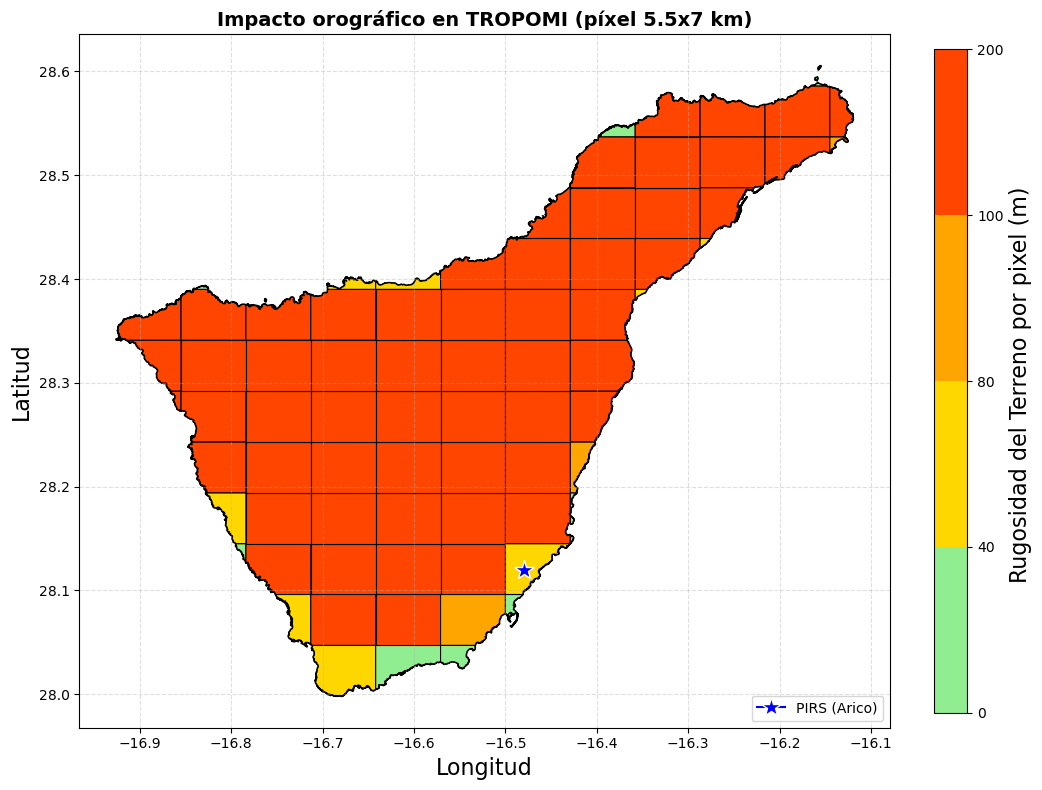

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.colors as mcolors
import osmnx as ox
from rasterstats import zonal_stats

print("1/3 - Descargando la silueta exacta de Tenerife...")
# Descargar la silueta real de Tenerife desde OpenStreetMap
tenerife = ox.geocode_to_gdf("Tenerife, Spain")

# Obtener los límites exactos de la isla para nuestra cuadrícula
lon_min, lat_min, lon_max, lat_max = tenerife.total_bounds

print("2/3 - Generando la cuadrícula de TROPOMI (5.5x7 km)...")
# Definir el tamaño del píxel de TROPOMI en grados
# Definir el tamaño del píxel de TROPOMI en grados (TUMBADO/HORIZONTAL)
ancho_pixel_deg = 0.071 # Longitud (aprox 7 km en horizontal)
alto_pixel_deg = 0.049  # Latitud (aprox 5.5 km en vertical)

# Crear la cuadrícula vacía
poligonos = []
for x in np.arange(lon_min, lon_max, ancho_pixel_deg):
    for y in np.arange(lat_min, lat_max, alto_pixel_deg):
        poligono = Polygon([(x, y), (x + ancho_pixel_deg, y), 
                            (x + ancho_pixel_deg, y + alto_pixel_deg), 
                            (x, y + alto_pixel_deg)])
        poligonos.append(poligono)

# Convertir a GeoDataFrame y recortar para que no dibuje el mar
grid = gpd.GeoDataFrame(geometry=poligonos, crs="EPSG:4326")
grid_isla = gpd.overlay(grid, tenerife, how='intersection')

print("3/3 - Calculando la rugosidad REAL cruzando con el mapa 3D...")
# ---------------------------------------------------------
# CÁLCULO REAL DE LA RUGOSIDAD (Desviación estándar de altitud)
# ---------------------------------------------------------
ruta_dem = "output_SRTMGL1.tif" 

# zonal_stats extrae la estadística 'std' (desviación estándar) del archivo .tif
estadisticas = zonal_stats(grid_isla, ruta_dem, stats="std")

# Guardamos el resultado en la cuadrícula (si algún punto da error/vacío, ponemos 0)
grid_isla['rugosidad_real'] = [stat['std'] if stat['std'] is not None else 0 for stat in estadisticas]

print("¡Listo! Dibujando el mapa...")
# ---------------------------------------------------------
# DIBUJAR EL MAPA FINAL
# ---------------------------------------------------------
# Configurar colores de la tabla de TROPOMI
# Verde (<20), Amarillo (20-40), Naranja (40-80), Rojo (>80, error alto)
cmap = mcolors.ListedColormap(['#90ee90', '#ffd700', '#ffa500', '#ff4500'])
bounds = [0, 40, 80, 100, 200] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Crear la figura
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujar la silueta de Tenerife de fondo
tenerife.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=1.5)

# Dibujar la cuadrícula con los datos reales de rugosidad
grid_isla.plot(column='rugosidad_real', ax=ax, cmap=cmap, norm=norm, 
               edgecolor='black', linewidth=0.8, alpha=1)

# Barra de colores (Leyenda)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Rugosidad del Terreno por pixel (m) ', fontsize=16)

# Añadir el punto del vertedero PIRS (Arico)
ax.plot(-16.48, 28.12, marker='*', color='blue', markersize=15, 
        markeredgecolor='white', label='PIRS (Arico)')

# Estética
plt.title('Impacto orográfico en TROPOMI (píxel 5.5x7 km)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Longitud', fontsize=16)
plt.ylabel('Latitud', fontsize=16)
plt.legend(loc='lower right')
plt.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()